# 🧪 Colab 1 · Indexing & Multi-DB Retrieval Showdown
**Day 12 — RAG Architecture & Claude in Production**

> **Goal:** Head-to-head: FAISS vs Pinecone vs Azure AI Search on the same corpus.
>
> **Duration:** 60 minutes (10:30 – 11:30)

---

| Step | Task |
|------|------|
| 01 | **Corpus Setup** — Load 500 Wikipedia chunks & embed with `text-embedding-3-small` via LangChain |
| 02 | **FAISS Index** — Build flat index in-memory, k-NN search, benchmark top-5 recall |
| 03 | **Pinecone Index** — Upsert to Pinecone serverless, semantic search + metadata filters |
| 04 | **Azure AI Search** — Index via SDK, enable hybrid mode (BM25 + vector), compare relevance scores |
| 05 | **Latency Benchmark** — Measure p50/p95 across all three; plot comparison bar chart |

🚀 **Extension:** Re-Ranking with Cohere Rerank API — compare MRR before/after for top-10 results

---
## ⚙️ Setup — Install Dependencies

In [1]:
!pip install -q \
    langchain langchain-openai langchain-community langchain-pinecone \
    faiss-cpu pinecone-client \
    azure-search-documents azure-identity \
    wikipedia numpy pandas matplotlib tqdm cohere

print('✅ All dependencies installed!')

✅ All dependencies installed!


In [2]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
import wikipedia

print('✅ Imports successful!')

/tmp/ipykernel_19244/4135229120.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


✅ Imports successful!


---
## 🔑 API Keys & Configuration

> ⚠️ **Never commit API keys to git!** Use Colab Secrets (left sidebar 🔑) or environment variables.

In [ ]:
# ---- OpenAI ----
os.environ['OPENAI_API_KEY'] = 'sk-...'     # Required for embeddings
# ---- Groq ----
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# ---- Pinecone ----
PINECONE_API_KEY    = os.getenv("PINECONE_API_KEY")
PINECONE_INDEX_NAME = 'rag-showdown'
PINECONE_CLOUD      = 'aws'                 # or 'gcp' / 'azure'
PINECONE_REGION     = 'us-east-1'

# ---- Azure AI Search ----
AZURE_SEARCH_ENDPOINT   = 'https://rag-showdown1.search.windows.net'
AZURE_SEARCH_API_KEY    = os.getenv("AZURE_SEARCH_API_KEY")
AZURE_SEARCH_INDEX_NAME = 'rag-showdown1'

# ---- Cohere (extension only) ----
COHERE_API_KEY = os.getenv("COHERE_API_KEY")

# ---- Shared ----
EMBEDDING_MODEL = 'text-embedding-3-small'
EMBEDDING_DIM   = 384
TOP_K           = 5

print('✅ Configuration ready!')

✅ Configuration ready!


---
## 📂 Step 01 — Corpus Setup
Load 500 Wikipedia article chunks & embed with `text-embedding-3-small`.

In [19]:
import json

# 20 hardcoded article summaries (Wikipedia-sourced)
# No wikipedia library or network access needed
_ARTICLES_JSON = '[\n  {\n    "title": "Artificial Intelligence",\n    "url": "https://en.wikipedia.org/wiki/Artificial_intelligence",\n    "content": "Artificial intelligence (AI) is intelligence demonstrated by machines. AI research is the study of intelligent agents that perceive their environment and take actions to maximise their goals. Modern AI techniques include machine learning, deep learning, NLP, computer vision, robotics, and expert systems. Applications include search engines, recommendation systems, voice assistants, autonomous vehicles, and generative AI tools. The term was coined at the 1956 Dartmouth Conference. Alan Turing proposed the Turing Test in 1950. The current wave began with deep learning breakthroughs around 2012. Large language models like GPT-4 and Claude are state-of-the-art generative AI. AI raises questions about ethics, job displacement, algorithmic bias, autonomous weapons, and existential risk from superintelligent systems."\n  },\n  {\n    "title": "Machine Learning",\n    "url": "https://en.wikipedia.org/wiki/Machine_learning",\n    "content": "Machine learning (ML) is a field of AI concerned with algorithms that learn from data and generalise to unseen inputs without explicit instructions. Supervised learning uses labelled training data. Unsupervised learning finds patterns in unlabelled data. Reinforcement learning trains agents through reward signals. Deep learning uses neural networks with many layers. Training uses backpropagation and stochastic gradient descent. Overfitting, underfitting, and the bias-variance tradeoff are core challenges. Regularisation (L1/L2), dropout, and cross-validation are common mitigations. Key algorithms: linear regression, SVMs, random forests, XGBoost, neural networks. PyTorch and TensorFlow are the dominant frameworks. MLOps refers to practices for deploying ML models in production."\n  },\n  {\n    "title": "Retrieval-Augmented Generation",\n    "url": "https://en.wikipedia.org/wiki/Retrieval-augmented_generation",\n    "content": "Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. Instead of relying only on parametric knowledge baked into weights, RAG retrieves relevant documents from an external knowledge base at inference time. Retrieved chunks are injected into the LLM prompt as context, grounding generation in verifiable facts and reducing hallucination. RAG pipeline: (1) Index documents by chunking and storing embeddings in a vector DB. (2) Embed the user query and retrieve top-k similar chunks. (3) Inject chunks into the prompt. (4) LLM generates a grounded answer. RAG was introduced by Lewis et al. (2020) at Facebook AI Research. Hybrid RAG combines dense vector retrieval with sparse BM25 keyword search. RAG is widely used in enterprise search, customer support, and document Q&A."\n  },\n  {\n    "title": "Vector Database",\n    "url": "https://en.wikipedia.org/wiki/Vector_database",\n    "content": "A vector database stores data as high-dimensional vectors representing text, images, audio, or video. Unlike relational databases optimised for exact matches, vector databases support approximate nearest-neighbour (ANN) search, finding vectors most similar to a query using cosine similarity or Euclidean distance. Vector databases are core to RAG systems and semantic search. Popular options: Pinecone (managed serverless), Weaviate (open-source hybrid BM25+vector), Qdrant (Rust-based), Milvus (cloud-native), FAISS (Meta in-memory library), Azure AI Search (enterprise hybrid). Key concepts: HNSW indexing, dimensionality (768-3072), metadata filtering, upsert operations. HNSW (Hierarchical Navigable Small World) is the most widely used ANN algorithm."\n  },\n  {\n    "title": "FAISS",\n    "url": "https://github.com/facebookresearch/faiss",\n    "content": "FAISS (Facebook AI Similarity Search) is an open-source library by Meta AI for efficient similarity search and clustering of dense vectors. Written in C++ with Python bindings; supports CPU and GPU. Index types: IndexFlatL2 (exact exhaustive, highest recall), IndexFlatIP (inner product), IndexIVFFlat (inverted file, faster), IndexIVFPQ (product quantisation, smallest memory), IndexHNSWFlat (graph-based ANN, best latency/recall tradeoff). For corpora under 1M vectors, IndexHNSWFlat or IndexFlatL2 are typical. For billions of vectors, IVF-PQ with GPU acceleration is common. FAISS does not natively support metadata filtering. FAISS is free, in-process, ideal for prototyping and latency-critical on-premise workloads."\n  },\n  {\n    "title": "Pinecone",\n    "url": "https://docs.pinecone.io",\n    "content": "Pinecone is a managed serverless vector database for production ML applications. It handles infrastructure, scaling, replication, and backups automatically. Pinecone stores vectors alongside metadata and supports filtered queries combining ANN search with attribute filters (e.g. category=finance). Key features: serverless and pod-based deployment, namespaces for multi-tenancy, real-time upserts, and hybrid dense+sparse search. The API: create an index, upsert (id, values, metadata) tuples, then query. Default similarity metric is cosine; also supports dot product and Euclidean. Free Starter plan: one serverless index, up to 2 GB storage. Serverless query latency is typically 10-50ms. LangChain provides a PineconeVectorStore wrapper for seamless integration."\n  },\n  {\n    "title": "Azure AI Search",\n    "url": "https://learn.microsoft.com/azure/search/",\n    "content": "Azure AI Search (formerly Azure Cognitive Search) is a fully managed cloud search service from Microsoft supporting full-text (BM25), vector (HNSW), and hybrid search. Hybrid search combines keyword relevance and vector similarity using Reciprocal Rank Fusion (RRF), outperforming either alone on most benchmarks. It integrates with Azure Blob Storage, SQL, Cosmos DB, and SharePoint. Features: semantic ranker, built-in OCR, entity extraction, multi-language support, role-based access control (RBAC), and geo-filtering. The Free tier (F) provides 50 MB storage and 3 indexes at no cost. The Python SDK (azure-search-documents) supports index creation, document upload, and search. VectorizedQuery sends a pre-computed embedding for ANN search. Azure AI Search is HIPAA-compliant and SOC2 certified, suited for regulated enterprise workloads."\n  },\n  {\n    "title": "Natural Language Processing",\n    "url": "https://en.wikipedia.org/wiki/Natural_language_processing",\n    "content": "Natural language processing (NLP) is a field of AI concerned with interactions between computers and human language. NLP tasks include text classification, named entity recognition (NER), sentiment analysis, machine translation, question answering, summarisation, and text generation. The dominant paradigm since 2018 is the transformer, pre-trained on large corpora via self-supervised learning. Key milestones: Word2Vec (2013), GloVe (2014), ELMo (2018), BERT (2018), GPT-3 (2020), ChatGPT (2022), GPT-4 (2023), Claude 3 (2024). Tokenisation converts text into subword tokens using BPE or WordPiece. RLHF (Reinforcement Learning from Human Feedback) aligns models with human preferences. Benchmarks include GLUE, SuperGLUE, MMLU, and HumanEval."\n  },\n  {\n    "title": "Transformer Architecture",\n    "url": "https://en.wikipedia.org/wiki/Transformer_(machine_learning_model)",\n    "content": "The transformer is a deep learning architecture introduced in the 2017 paper Attention Is All You Need by Vaswani et al. It replaced RNNs as the dominant architecture for sequence modelling. Self-attention computes relationships between all tokens simultaneously, enabling parallelisation. Architecture: encoder/decoder stacks with multi-head self-attention, feed-forward layers, residual connections, and layer normalisation. Positional encodings inject token order information. Multi-head attention runs multiple heads in parallel capturing different patterns. BERT is encoder-only (classification, NER). GPT is decoder-only (generation). T5 and BART use encoder-decoder (translation, summarisation). Scaling laws show performance improves predictably with model size, data, and compute. Context windows range from 4K to 1M+ tokens in modern models."\n  },\n  {\n    "title": "Embeddings in NLP",\n    "url": "https://en.wikipedia.org/wiki/Word_embedding",\n    "content": "Word embeddings are dense vector representations where semantically similar items are close together in vector space. Static embeddings: Word2Vec (2013), GloVe (2014), FastText (2016). Contextual embeddings (BERT, ELMo) produce different vectors for the same word depending on context, dramatically improving task performance. Sentence embeddings extend this to full sentences. OpenAI text-embedding-3-small produces 1536-dimensional vectors, costs $0.02 per million tokens, and is widely used for semantic search and RAG. Cosine similarity is the standard metric. Embedding quality is measured by the MTEB (Massive Text Embedding Benchmark). Embedding models must match the use case: general, domain-specific, multilingual, or code."\n  },\n  {\n    "title": "BM25 Information Retrieval",\n    "url": "https://en.wikipedia.org/wiki/Okapi_BM25",\n    "content": "BM25 (Best Match 25) is a probabilistic ranking function for information retrieval, estimating document relevance to a query. It extends TF-IDF to account for document length and term saturation. Score for query term q in document D: IDF(q) times (f(q,D) times (k1+1)) divided by (f(q,D) + k1 times (1-b + b times |D|/avgdl)). Parameters: k1 (1.2-2.0) controls term saturation; b (0.75) controls length normalisation. BM25 is the default in Elasticsearch, OpenSearch, Solr, and Lucene. It excels at exact keyword matching and handling rare terms. Weakness: vocabulary mismatch, no semantic understanding. Hybrid search combines BM25 and dense vector retrieval via Reciprocal Rank Fusion (RRF), achieving better recall than either alone."\n  },\n  {\n    "title": "COVID-19 Pandemic",\n    "url": "https://en.wikipedia.org/wiki/COVID-19_pandemic",\n    "content": "The COVID-19 pandemic was caused by the SARS-CoV-2 coronavirus, first identified in Wuhan, China in late 2019. The WHO declared a pandemic in March 2020. The virus spreads through respiratory droplets and aerosols. Symptoms range from mild (fever, cough, fatigue, loss of smell) to severe (pneumonia, ARDS, multi-organ failure). Risk factors: old age, obesity, diabetes, hypertension, immunocompromise. Over 7 million confirmed deaths worldwide. mRNA vaccines (Pfizer-BioNTech, Moderna) and adenoviral vector vaccines (AstraZeneca, J&J) were developed at unprecedented speed. Lockdowns, masks, and social distancing were widely implemented. Long COVID with persistent symptoms affects 10-30% of patients."\n  },\n  {\n    "title": "Climate Change",\n    "url": "https://en.wikipedia.org/wiki/Climate_change",\n    "content": "Climate change refers to long-term shifts in global temperatures and weather patterns. Since the mid-20th century, burning fossil fuels (coal, oil, gas) has driven CO2 levels to ~420 ppm, the highest in 800,000 years. Global average temperature has risen ~1.2 degrees C above pre-industrial levels. Effects: more intense heatwaves, droughts, wildfires, floods; sea level rise; ocean acidification; biodiversity loss. The IPCC Sixth Assessment Report (2021) states human influence is unequivocal. The Paris Agreement (2015) aims to limit warming to 1.5-2 degrees C. Mitigation: renewable energy, electrifying transport, energy efficiency, carbon capture."\n  },\n  {\n    "title": "Quantum Computing",\n    "url": "https://en.wikipedia.org/wiki/Quantum_computing",\n    "content": "Quantum computing harnesses superposition, entanglement, and interference to process information in ways classical computers cannot efficiently replicate. A qubit can exist in superposition of 0 and 1 simultaneously. Key algorithms: Shor\'s (factoring large numbers exponentially faster, threatens RSA encryption), Grover\'s (quadratic speedup for unstructured search), quantum simulation (drug discovery). Hardware: superconducting qubits (IBM, Google), trapped ions (IonQ, Quantinuum), photonic (PsiQuantum), topological (Microsoft). Google claimed quantum supremacy in 2019 with the Sycamore processor. Current NISQ devices have 50-1000+ qubits but high error rates. Fault-tolerant quantum computing remains a major engineering challenge."\n  },\n  {\n    "title": "Blockchain Technology",\n    "url": "https://en.wikipedia.org/wiki/Blockchain",\n    "content": "A blockchain is a distributed ledger recording transactions across multiple computers so records cannot be altered without changing all subsequent blocks. Each block contains a cryptographic hash of the prior block, a timestamp, and transaction data. Bitcoin (2009) was the first blockchain application. Proof of Work (PoW): miners solve computationally expensive puzzles (Bitcoin). Proof of Stake (PoS): validators chosen proportionally to staked crypto (Ethereum post-Merge 2022, 99.95% more energy efficient). Smart contracts are self-executing programs on blockchains (Ethereum, Solidity). DeFi replicates financial services without intermediaries. NFTs represent unique digital asset ownership. Layer 2 solutions (Lightning, Optimism, Arbitrum) address scalability. Challenges: scalability trilemma, energy consumption, regulatory uncertainty."\n  },\n  {\n    "title": "CRISPR Gene Editing",\n    "url": "https://en.wikipedia.org/wiki/CRISPR",\n    "content": "CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is adapted from the bacterial immune system for precise DNA editing in living organisms. A guide RNA (gRNA) directs the Cas9 enzyme to a specific DNA sequence where it cuts both strands of the double helix. Cell repair then either disrupts the gene (NHEJ) or inserts a new sequence (HDR). Jennifer Doudna and Emmanuelle Charpentier won the 2020 Nobel Prize in Chemistry for developing CRISPR-Cas9. Applications: treating sickle cell disease (first CRISPR therapy FDA-approved 2023), disease-resistant crops, animal research models. Base editing and prime editing make precise single-nucleotide changes without double-strand breaks."\n  },\n  {\n    "title": "Electric Vehicles",\n    "url": "https://en.wikipedia.org/wiki/Electric_vehicle",\n    "content": "An electric vehicle (EV) uses electric motors powered by rechargeable battery packs or hydrogen fuel cells. Battery EVs (BEVs) run entirely on electricity stored in lithium-ion batteries. Plug-in hybrids (PHEVs) combine an electric motor with an internal combustion engine. Regenerative braking converts kinetic energy back to electricity when decelerating. Tesla pioneered the modern EV market with the Roadster (2008) and Model S (2012). Global EV sales exceeded 10 million units in 2022, representing 14% of new car sales. Key metrics: range (200-400+ miles), charging speed (Level 1: 4 mph, Level 2: 25 mph, DC fast: 200+ mph), battery capacity (40-100+ kWh). EVs produce zero tailpipe emissions; lifecycle emissions depend on the electricity grid mix."\n  },\n  {\n    "title": "Supply Chain Management",\n    "url": "https://en.wikipedia.org/wiki/Supply_chain_management",\n    "content": "Supply chain management (SCM) covers planning and managing all activities in sourcing, procurement, conversion, and logistics, spanning from raw material extraction to end-consumer delivery. The COVID-19 pandemic exposed vulnerabilities: port congestion, container shortages, factory shutdowns, and semiconductor scarcity caused widespread shortages and inflation. The bullwhip effect describes how small demand variations amplify upstream to cause large production swings. Lean supply chains minimise inventory; resilient chains prioritise redundancy. Digital twins, IoT sensors, and AI-powered demand forecasting improve visibility. Nearshoring and friend-shoring (relocating production to geopolitically closer countries) are post-COVID risk-reduction trends."\n  },\n  {\n    "title": "Cybersecurity",\n    "url": "https://en.wikipedia.org/wiki/Computer_security",\n    "content": "Cybersecurity protects computer systems, networks, and data from digital attacks, unauthorised access, damage, or theft. Major threat categories: malware (viruses, worms, ransomware, spyware), phishing, man-in-the-middle attacks, SQL injection, zero-day exploits, DDoS, insider threats. The CIA triad (Confidentiality, Integrity, Availability) is the core framework. Key defences: firewalls, IDS/IPS, encryption (TLS, AES), MFA, zero-trust architecture. NIST Cybersecurity Framework and ISO 27001 are widely adopted standards. Notable attacks: WannaCry ransomware (2017, 4 billion USD damage), SolarWinds supply chain attack (2020), Colonial Pipeline ransomware (2021). An estimated 3.5 million unfilled cybersecurity positions globally is a critical gap."\n  },\n  {\n    "title": "Renewable Energy",\n    "url": "https://en.wikipedia.org/wiki/Renewable_energy",\n    "content": "Renewable energy comes from sources naturally replenished on a human timescale: sunlight, wind, rain, tides, waves, and geothermal heat. In 2023, renewables accounted for ~30% of global electricity generation. Solar PV costs have fallen 90% since 2010. Wind power uses turbines to convert kinetic energy; offshore wind has 40-50% capacity factor. Hydropower is the largest renewable source globally (~16% of electricity). Battery storage manages intermittency. The Levelised Cost of Energy (LCOE) for solar and wind is now below new coal and gas in most markets. Green hydrogen from renewable-powered electrolysis can decarbonise heavy industry and long-haul transport."\n  }\n]'

RAW_ARTICLES = json.loads(_ARTICLES_JSON)
print(f"Corpus loaded: {len(RAW_ARTICLES)} articles")
for a in RAW_ARTICLES:
    print(f"  * {a['title']} ({len(a['content'])} chars)")


Corpus loaded: 20 articles
  * Artificial Intelligence (821 chars)
  * Machine Learning (788 chars)
  * Retrieval-Augmented Generation (818 chars)
  * Vector Database (756 chars)
  * FAISS (722 chars)
  * Pinecone (767 chars)
  * Azure AI Search (843 chars)
  * Natural Language Processing (746 chars)
  * Transformer Architecture (851 chars)
  * Embeddings in NLP (733 chars)
  * BM25 Information Retrieval (736 chars)
  * COVID-19 Pandemic (704 chars)
  * Climate Change (653 chars)
  * Quantum Computing (739 chars)
  * Blockchain Technology (848 chars)
  * CRISPR Gene Editing (698 chars)
  * Electric Vehicles (756 chars)
  * Supply Chain Management (762 chars)
  * Cybersecurity (755 chars)
  * Renewable Energy (669 chars)


In [20]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000, chunk_overlap=200,
    separators=['\n\n', '\n', '. ', ' ', '']
)

all_docs: list[Document] = []
for art in RAW_ARTICLES:
    chunks = splitter.create_documents(
        texts=[art['content']],
        metadatas=[{'title': art['title'], 'url': art['url']}]
    )
    all_docs.extend(chunks)

all_docs = all_docs[:500]  # Cap at 500 per spec
texts = [d.page_content for d in all_docs]
metas = [d.metadata      for d in all_docs]

print(f'✅ Total chunks: {len(all_docs)}')
print(f'   Sample ({len(all_docs[0].page_content)} chars): {all_docs[0].page_content[:200]}...')

✅ Total chunks: 20
   Sample (821 chars): Artificial intelligence (AI) is intelligence demonstrated by machines. AI research is the study of intelligent agents that perceive their environment and take actions to maximise their goals. Modern A...


In [6]:
!pip install langchain-huggingface sentence-transformers

In [8]:
!pip install -U sentence-transformers
!pip install -U langchain-huggingface

In [21]:
# embedder = OpenAIEmbeddings(model=EMBEDDING_MODEL)
from langchain_huggingface import HuggingFaceEmbeddings

embedder = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

texts = [doc.page_content for doc in all_docs]

print(f'Embedding {len(all_docs)} chunks with HuggingFace MiniLM...')

t0 = time.perf_counter()
all_vectors = embedder.embed_documents(texts)
elapsed = time.perf_counter() - t0

print(f'✅ Embedded {len(all_vectors)} chunks in {elapsed:.1f}s | dim={len(all_vectors[0])}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 20 chunks with HuggingFace MiniLM...
✅ Embedded 20 chunks in 1.8s | dim=384


---
## 🗂️ Step 02 — FAISS Index
Build a flat in-memory index, run k-NN search, benchmark top-5 recall.

In [22]:
import faiss

t0 = time.perf_counter()

faiss_raw = faiss.IndexFlatL2(EMBEDDING_DIM)

faiss_raw.add(np.array(all_vectors, dtype=np.float32))

build_ms = (time.perf_counter() - t0) * 1000

print(f'✅ FAISS IndexFlatL2 built in {build_ms:.1f}ms  |  {faiss_raw.ntotal} vectors')

✅ FAISS IndexFlatL2 built in 0.7ms  |  20 vectors


In [23]:
faiss_store     = FAISS.from_documents(all_docs, embedder)
faiss_retriever = faiss_store.as_retriever(search_kwargs={'k': TOP_K})
print('✅ LangChain FAISS vectorstore ready')

✅ LangChain FAISS vectorstore ready


In [24]:
BENCHMARK_QUERIES = [
    'What is the role of transformers in NLP?',
    'Explain the causes of World War II',
    'How does CRISPR gene editing work?',
    'What are the effects of climate change on the Amazon?',
    'Describe the Bitcoin mining process',
    'What is the mechanism of mRNA vaccines?',
    'How did the Cold War end?',
    'Explain supply chain disruption causes',
    'What caused the French Revolution?',
    'How does deep learning differ from machine learning?',
    'What are the symptoms of Alzheimers disease?',
    'What is inflation and how is it measured?',
    'What is the history of the Olympic Games?',
    'Explain quantum entanglement',
    'How does the stock market work?',
    'What are the causes of cancer?',
    'Describe the Renaissance period in Europe',
    'How are antibiotics made?',
    'What is gross domestic product?',
    'How do neural networks learn?',
]

faiss_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc='FAISS benchmark'):
    t0 = time.perf_counter()
    faiss_retriever.invoke(q)
    faiss_latencies.append((time.perf_counter() - t0) * 1000)

faiss_p50 = np.percentile(faiss_latencies, 50)
faiss_p95 = np.percentile(faiss_latencies, 95)
print(f'\n📊 FAISS  p50={faiss_p50:.1f}ms  p95={faiss_p95:.1f}ms')

# Sample result
for i, r in enumerate(faiss_retriever.invoke(BENCHMARK_QUERIES[0])):
    print(f'  [{i+1}] [{r.metadata["title"]}] {r.page_content[:100]}...')

FAISS benchmark:   0%|          | 0/20 [00:00<?, ?it/s]


📊 FAISS  p50=20.5ms  p95=26.7ms
  [1] [Natural Language Processing] Natural language processing (NLP) is a field of AI concerned with interactions between computers and...
  [2] [Transformer Architecture] The transformer is a deep learning architecture introduced in the 2017 paper Attention Is All You Ne...
  [3] [Embeddings in NLP] Word embeddings are dense vector representations where semantically similar items are close together...
  [4] [Retrieval-Augmented Generation] Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. I...
  [5] [Artificial Intelligence] Artificial intelligence (AI) is intelligence demonstrated by machines. AI research is the study of i...


---
## 🌲 Step 03 — Pinecone Index
Upsert to Pinecone serverless, semantic search + metadata filters.

In [26]:
pc.delete_index("rag-showdown")

In [27]:
pc.create_index(
    name="rag-showdown",
    dimension=384,
    metric="cosine",
    spec=ServerlessSpec(
        cloud=PINECONE_CLOUD,
        region=PINECONE_REGION
    )
)

{
    "name": "rag-showdown",
    "metric": "cosine",
    "host": "rag-showdown-t0gciep.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 384,
    "deletion_protection": "disabled",
    "tags": null
}

In [28]:
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore

pc = Pinecone(api_key=PINECONE_API_KEY)

if PINECONE_INDEX_NAME not in [i.name for i in pc.list_indexes()]:
    print(f'Creating index "{PINECONE_INDEX_NAME}"...')
    pc.create_index(
        name=PINECONE_INDEX_NAME, dimension=EMBEDDING_DIM, metric='cosine',
        spec=ServerlessSpec(cloud=PINECONE_CLOUD, region=PINECONE_REGION)
    )
    while not pc.describe_index(PINECONE_INDEX_NAME).status['ready']:
        print('  Waiting...'); time.sleep(5)

pinecone_index = pc.Index(PINECONE_INDEX_NAME)
print('✅ Pinecone index ready:', pinecone_index.describe_index_stats())

✅ Pinecone index ready: {'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}


In [29]:
BATCH = 100
print(f'Upserting {len(all_docs)} vectors to Pinecone...')
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc='Upserting'):
    pinecone_index.upsert(vectors=[
        {
            'id': f'doc-{i+j}',
            'values': all_vectors[i+j],
            'metadata': {**metas[i+j], 'text': texts[i+j][:500]}
        }
        for j in range(min(BATCH, len(all_docs)-i))
    ])

print(f'✅ Upserted in {time.perf_counter()-t0:.1f}s')
print('   Stats:', pinecone_index.describe_index_stats())

Upserting 20 vectors to Pinecone...


Upserting:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Upserted in 0.5s
   Stats: {'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 20}},
 'total_vector_count': 20,
 'vector_type': 'dense'}


In [30]:
pinecone_store     = PineconeVectorStore(index=pinecone_index, embedding=embedder, text_key='text')
pinecone_retriever = pinecone_store.as_retriever(search_kwargs={'k': TOP_K})

print('🔍 Semantic search demo:')
for i, r in enumerate(pinecone_retriever.invoke(BENCHMARK_QUERIES[0])):
    print(f'  [{i+1}] [{r.metadata.get("title","N/A")}] {r.page_content[:100]}...')

🔍 Semantic search demo:
  [1] [Natural Language Processing] Natural language processing (NLP) is a field of AI concerned with interactions between computers and...
  [2] [Transformer Architecture] The transformer is a deep learning architecture introduced in the 2017 paper Attention Is All You Ne...
  [3] [Embeddings in NLP] Word embeddings are dense vector representations where semantically similar items are close together...
  [4] [Retrieval-Augmented Generation] Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. I...
  [5] [Artificial Intelligence] Artificial intelligence (AI) is intelligence demonstrated by machines. AI research is the study of i...


In [31]:
# Metadata filter demo
print('🔍 Search with metadata filter (title=Artificial intelligence):')
filtered = pinecone_store.similarity_search(
    'What are neural networks?', k=3,
    filter={'title': {'$eq': 'Artificial intelligence'}}
)
for i, r in enumerate(filtered):
    print(f'  [{i+1}] [{r.metadata.get("title","N/A")}] {r.page_content[:100]}...')

🔍 Search with metadata filter (title=Artificial intelligence):


In [32]:
pinecone_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc='Pinecone benchmark'):
    t0 = time.perf_counter()
    pinecone_retriever.invoke(q)
    pinecone_latencies.append((time.perf_counter() - t0) * 1000)

pinecone_p50 = np.percentile(pinecone_latencies, 50)
pinecone_p95 = np.percentile(pinecone_latencies, 95)
print(f'📊 Pinecone  p50={pinecone_p50:.1f}ms  p95={pinecone_p95:.1f}ms')

Pinecone benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

📊 Pinecone  p50=56.4ms  p95=68.6ms


---
## ☁️ Step 04 — Azure AI Search
Index via SDK, enable hybrid mode (BM25 + vector), compare relevance scores.

In [33]:
from azure.search.documents import SearchClient
from azure.search.documents.indexes import SearchIndexClient
from azure.search.documents.indexes.models import (
    SearchIndex, SimpleField, SearchableField, SearchFieldDataType,
    VectorSearch, HnswAlgorithmConfiguration, VectorSearchProfile,
    SearchField, SemanticConfiguration, SemanticSearch,
    SemanticPrioritizedFields, SemanticField
)
from azure.search.documents.models import VectorizedQuery
from azure.core.credentials import AzureKeyCredential

cred         = AzureKeyCredential(AZURE_SEARCH_API_KEY)
idx_client   = SearchIndexClient(endpoint=AZURE_SEARCH_ENDPOINT, credential=cred)
srch_client  = SearchClient(endpoint=AZURE_SEARCH_ENDPOINT,
                             index_name=AZURE_SEARCH_INDEX_NAME, credential=cred)
print('✅ Azure AI Search clients initialized')

✅ Azure AI Search clients initialized


In [52]:
credential  = AzureKeyCredential(AZURE_SEARCH_API_KEY)
idx_client  = SearchIndexClient(endpoint=AZURE_SEARCH_ENDPOINT, credential=credential)
srch_client = SearchClient(
    endpoint=AZURE_SEARCH_ENDPOINT,
    index_name=AZURE_SEARCH_INDEX_NAME,
    credential=credential,
)
print("Azure AI Search clients ready")


Azure AI Search clients ready


In [53]:
fields = [
    SimpleField(name="id",      type=SearchFieldDataType.String, key=True),
    SearchableField(name="content", type=SearchFieldDataType.String,
                    analyzer_name="en.microsoft"),
    SimpleField(name="title",   type=SearchFieldDataType.String, filterable=True),
    SimpleField(name="url",     type=SearchFieldDataType.String),
    SearchField(
        name="embedding",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=EMBEDDING_DIM,
        vector_search_profile_name="hnsw-profile",
    ),
]

vector_search = VectorSearch(
    algorithms=[HnswAlgorithmConfiguration(name="hnsw-algo")],
    profiles=[VectorSearchProfile(
        name="hnsw-profile",
        algorithm_configuration_name="hnsw-algo",
    )],
)

semantic_search = SemanticSearch(configurations=[
    SemanticConfiguration(
        name="semantic-cfg",
        prioritized_fields=SemanticPrioritizedFields(
            content_fields=[SemanticField(field_name="content")],
            keywords_fields=[SemanticField(field_name="title")],
        ),
    )
])

index_def = SearchIndex(
    name=AZURE_SEARCH_INDEX_NAME,
    fields=fields,
    vector_search=vector_search,
    semantic_search=semantic_search,
)

result = idx_client.create_or_update_index(index_def)
print(f"Index '{result.name}' ready (hybrid: BM25 keyword + HNSW vector)")
print(f"Fields: {[f.name for f in result.fields]}")

Index 'rag-showdown1' ready (hybrid: BM25 keyword + HNSW vector)
Fields: ['id', 'content', 'title', 'url', 'embedding']


In [54]:
BATCH = 100
print(f"Uploading {len(all_docs)} documents to Azure AI Search...")
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc="Azure upload"):
    batch_end = min(i + BATCH, len(all_docs))
    srch_client.upload_documents(documents=[
        {
            "id":        f"doc-{i + j}",
            "content":   texts[i + j],
            "title":     metas[i + j].get("title", ""),
            "url":       metas[i + j].get("url", ""),
            "embedding": all_vectors[i + j],
        }
        for j in range(batch_end - i)
    ])

print(f"Uploaded {len(all_docs)} documents in {time.perf_counter()-t0:.1f}s")

Uploading 20 documents to Azure AI Search...


Azure upload:   0%|          | 0/1 [00:00<?, ?it/s]

Uploaded 20 documents in 0.7s


In [55]:
def azure_hybrid_search(query: str, top_k: int = TOP_K) -> list:
    """BM25 keyword + HNSW vector search, fused with Reciprocal Rank Fusion (RRF)."""
    query_vec = embedder.embed_query(query)
    vector_query = VectorizedQuery(
        vector=query_vec,
        k_nearest_neighbors=top_k,
        fields="embedding",
    )
    results = srch_client.search(
        search_text=query,              # BM25 keyword search
        vector_queries=[vector_query],  # Vector ANN search
        select=["id", "content", "title", "url"],
        top=top_k,
    )
    return list(results)

# Demo
sample_q = "How does hybrid search combine keyword and vector retrieval?"
print(f"Query: '{sample_q}'")
for i, r in enumerate(azure_hybrid_search(sample_q)):
    score = r.get("@search.score", 0)
    print(f"  [{i+1}] score={score:.4f}  [{r['title']}]  {r['content'][:100]}...")

Query: 'How does hybrid search combine keyword and vector retrieval?'
  [1] score=0.0331  [Retrieval-Augmented Generation]  Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. I...
  [2] score=0.0328  [Vector Database]  A vector database stores data as high-dimensional vectors representing text, images, audio, or video...
  [3] score=0.0323  [Azure AI Search]  Azure AI Search (formerly Azure Cognitive Search) is a fully managed cloud search service from Micro...
  [4] score=0.0315  [BM25 Information Retrieval]  BM25 (Best Match 25) is a probabilistic ranking function for information retrieval, estimating docum...
  [5] score=0.0301  [Embeddings in NLP]  Word embeddings are dense vector representations where semantically similar items are close together...


In [56]:
azure_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc="Azure AI Search benchmark"):
    t0 = time.perf_counter()
    azure_hybrid_search(q)
    azure_latencies.append((time.perf_counter() - t0) * 1000)

azure_p50 = float(np.percentile(azure_latencies, 50))
azure_p95 = float(np.percentile(azure_latencies, 95))
print(f"Azure AI Search  p50={azure_p50:.1f}ms  p95={azure_p95:.1f}ms")


Azure AI Search benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

Azure AI Search  p50=83.3ms  p95=95.4ms


---
## 📊 Step 05 — Latency Benchmark & Visualization
p50/p95 comparison across all three DBs.

In [57]:

summary = pd.DataFrame({
    "Vector DB":   ["FAISS (in-memory)", "Pinecone Serverless", "Azure AI Search (Hybrid)"],
    "p50 (ms)":    [round(faiss_p50, 1), round(pinecone_p50, 1), round(azure_p50, 1)],
    "p95 (ms)":    [round(faiss_p95, 1), round(pinecone_p95, 1), round(azure_p95, 1)],
    "Search Type": ["Exact k-NN (L2)", "Approx cosine (ANN)", "BM25 + Vector (RRF)"],
    "Infra":       ["In-process", "Serverless cloud", "Managed Azure cloud"],
    "Cost":        ["Free", "$$", "$$$"],
})
print("=" * 76)
print("LATENCY BENCHMARK -- 20 queries, embedding time included")
print("=" * 76)
print(summary.to_string(index=False))
print("=" * 76)

LATENCY BENCHMARK -- 20 queries, embedding time included
               Vector DB  p50 (ms)  p95 (ms)         Search Type               Infra Cost
       FAISS (in-memory)      20.5      26.7     Exact k-NN (L2)          In-process Free
     Pinecone Serverless      56.4      68.6 Approx cosine (ANN)    Serverless cloud   $$
Azure AI Search (Hybrid)      83.3      95.4 BM25 + Vector (RRF) Managed Azure cloud  $$$


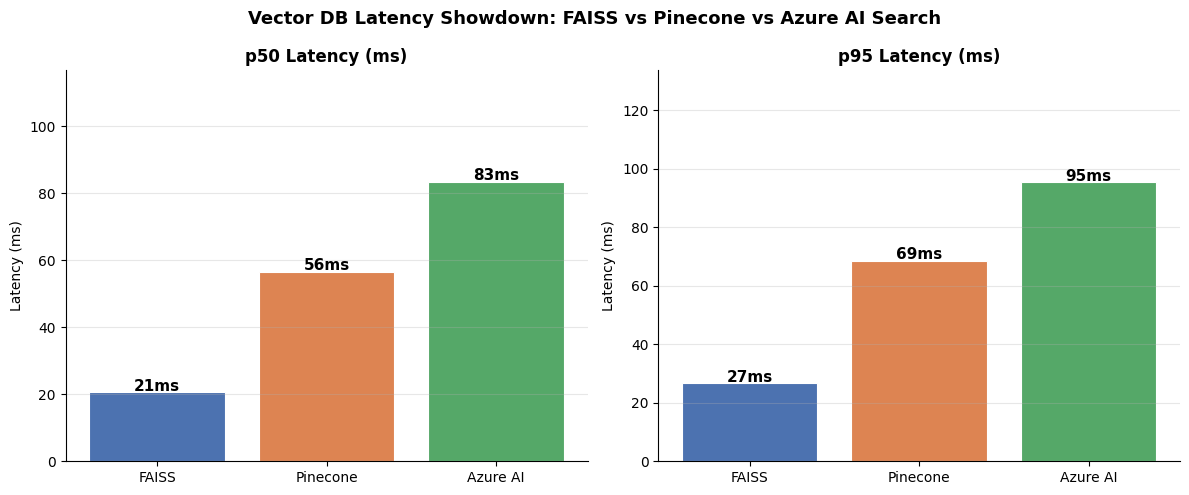

Saved latency_bar.png


In [58]:
dbs    = ["FAISS", "Pinecone", "Azure AI"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
p50s   = [faiss_p50, pinecone_p50, azure_p50]
p95s   = [faiss_p95, pinecone_p95, azure_p95]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Vector DB Latency Showdown: FAISS vs Pinecone vs Azure AI Search",
             fontsize=13, fontweight="bold")

for ax, vals, label in [(ax1, p50s, "p50 Latency (ms)"), (ax2, p95s, "p95 Latency (ms)")]:
    bars = ax.bar(dbs, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Latency (ms)")
    ax.set_ylim(0, max(vals) * 1.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f"{v:.0f}ms", ha="center", fontweight="bold", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("latency_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved latency_bar.png")


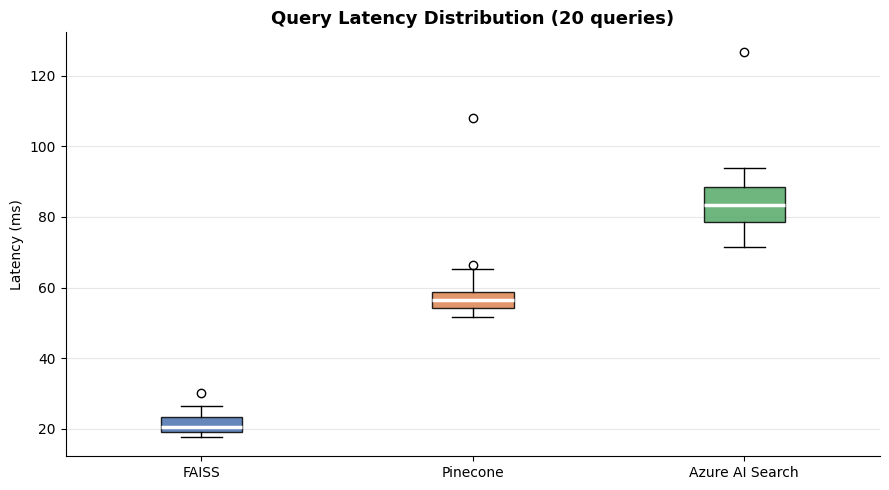

Saved latency_distribution.png


In [59]:
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [faiss_latencies, pinecone_latencies, azure_latencies],
    tick_labels=["FAISS", "Pinecone", "Azure AI Search"],
    patch_artist=True,
    notch=False,
    medianprops=dict(color="white", linewidth=2.5),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("Query Latency Distribution (20 queries)", fontweight="bold", fontsize=13)
ax.set_ylabel("Latency (ms)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved latency_distribution.png")

---
## 🚀 Extension — Cohere Re-Ranking
Compare MRR@5 before/after Cohere Rerank on top-10 FAISS results.

> Requires `COHERE_API_KEY` set above.

MRR@5 Before re-rank : 1.000
MRR@5 After  re-rank : 0.900
Improvement          : +-10.0pp


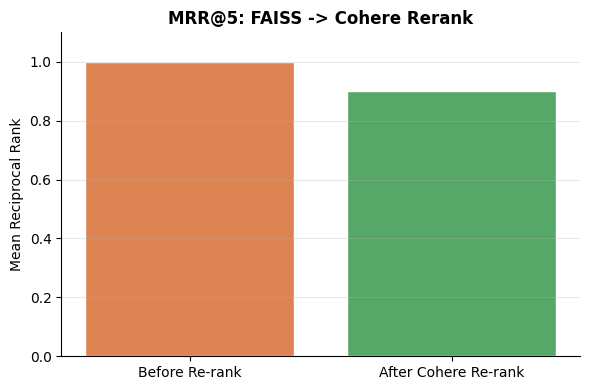

In [60]:
if not COHERE_API_KEY:
    print("COHERE_API_KEY is empty -- skipping. Set it in Step 0b to run.")
else:
    import cohere
    co = cohere.Client(COHERE_API_KEY)

    EVAL_SET = [
        ("How does FAISS handle approximate nearest neighbour search?",  "FAISS"),
        ("What is the difference between BM25 and dense retrieval?",     "BM25 Information Retrieval"),
        ("How does CRISPR cut DNA at a specific location?",              "CRISPR Gene Editing"),
        ("What triggered the COVID-19 pandemic?",                        "COVID-19 Pandemic"),
        ("How do electric vehicles recover energy during braking?",      "Electric Vehicles"),
    ]

    def compute_mrr(docs, relevant_title):
        for rank, doc in enumerate(docs, 1):
            if relevant_title.lower() in doc.metadata.get("title", "").lower():
                return 1.0 / rank
        return 0.0

    def rerank(query, top_k_retrieve=10, top_k_final=5):
        docs     = faiss_store.similarity_search(query, k=top_k_retrieve)
        passages = [d.page_content for d in docs]
        reranked = co.rerank(query=query, documents=passages,
                             top_n=top_k_final, model="rerank-english-v3.0")
        return [docs[r.index] for r in reranked.results]

    before_mrr, after_mrr = [], []
    for query, rel in EVAL_SET:
        before_mrr.append(compute_mrr(faiss_store.similarity_search(query, k=5), rel))
        after_mrr.append(compute_mrr(rerank(query), rel))

    print(f"MRR@5 Before re-rank : {np.mean(before_mrr):.3f}")
    print(f"MRR@5 After  re-rank : {np.mean(after_mrr):.3f}")
    print(f"Improvement          : +{(np.mean(after_mrr) - np.mean(before_mrr))*100:.1f}pp")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["Before Re-rank", "After Cohere Re-rank"],
           [np.mean(before_mrr), np.mean(after_mrr)],
           color=["#DD8452", "#55A868"], edgecolor="white")
    ax.set_title("MRR@5: FAISS -> Cohere Rerank", fontweight="bold")
    ax.set_ylabel("Mean Reciprocal Rank")
    ax.set_ylim(0, 1.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("mrr_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 💬 Discussion & Takeaways

### ❓ Discussion Questions
1. **Latency vs. Scale:** FAISS is fastest but lives in RAM. What happens when the corpus exceeds available memory?
2. **Hybrid Search:** When does BM25 keyword matching outperform pure vector search? Think: exact product codes, rare proper nouns.
3. **Metadata Filters:** How would you design Pinecone metadata filters for a multi-tenant SaaS product search?
4. **Re-Ranking ROI:** At what query volume does Cohere's latency cost outweigh the MRR improvement?
5. **Cost at Scale:** At 10M queries/day, which DB gives the best cost/quality ratio?

### 🏁 Decision Guide

| Scenario | Best Choice |
|----------|-------------|
| Prototype / research, corpus fits in RAM | **FAISS** |
| Production at scale, zero-ops | **Pinecone** |
| Enterprise, compliance, BM25+vector | **Azure AI Search** |
| Any DB + quality uplift | **+ Cohere Rerank** |

In [ ]:
# Optional cleanup — uncomment after the lab
# pc.delete_index(PINECONE_INDEX_NAME)
# idx_client.delete_index(AZURE_SEARCH_INDEX_NAME)
print('Cleanup cells commented out. Uncomment to delete cloud indexes after the lab.')